# Assignment 13.2 - Generative Models



## Task 13.2.1 - Flow Matching

* Implement a small flow matching model and training loop. **(RESULT)**
* Train the flow matching model on the CIFAR10 dataset. **(RESULT)**

Feel free to go based on the live coding example from the lecture.

In [ ]:
import math
import torch
from torch import nn


class TimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half, device=t.device, dtype=t.dtype) / half
        )
        t = t.view(-1, 1)
        args = t * freqs.view(1, -1)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = torch.nn.functional.pad(emb, (0, 1))
        return self.mlp(emb)


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)

        t = self.time_proj(t_emb).view(t_emb.size(0), -1, 1, 1)
        h = h + t

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)
        return h + self.skip(x)


class FlowMatchingUNet(nn.Module):
    def __init__(self, in_ch: int = 3, base_ch: int = 64, time_dim: int = 128):
        super().__init__()
        self.time_embed = TimeEmbedding(time_dim)

        self.in_conv = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1)

        self.down1 = ResBlock(base_ch, base_ch * 2, time_dim)
        self.down2 = ResBlock(base_ch * 2, base_ch * 4, time_dim)
        self.downsample = nn.AvgPool2d(2)

        self.mid = ResBlock(base_ch * 4, base_ch * 4, time_dim)

        self.up1 = ResBlock(base_ch * 8, base_ch * 2, time_dim)
        self.up2 = ResBlock(base_ch * 4, base_ch, time_dim)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(base_ch, in_ch, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_embed(t)

        x = self.in_conv(x)
        d1 = self.down1(x, t_emb)
        x = self.downsample(d1)

        d2 = self.down2(x, t_emb)
        x = self.downsample(d2)

        x = self.mid(x, t_emb)

        x = self.upsample(x)
        x = torch.cat([x, d2], dim=1)
        x = self.up1(x, t_emb)

        x = self.upsample(x)
        x = torch.cat([x, d1], dim=1)
        x = self.up2(x, t_emb)

        x = self.out_norm(x)
        x = self.out_act(x)
        return self.out_conv(x)



In [ ]:
import argparse
import os
from dataclasses import dataclass

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm


@dataclass
class TrainConfig:
    data_dir: str = "./data"
    batch_size: int = 128
    num_workers: int = 4
    epochs: int = 20
    lr: float = 2e-4
    weight_decay: float = 1e-4
    image_size: int = 32
    base_ch: int = 64
    time_dim: int = 128
    save_dir: str = "./runs"
    sample_every: int = 1
    sample_steps: int = 50
    seed: int = 0
    download: bool = True
    device: str = "auto"


def resolve_device(device: str) -> str:
    if device != "auto":
        return device
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def make_dataloaders(cfg: TrainConfig):
    transform = transforms.Compose(
        [
            transforms.Resize(cfg.image_size),
            transforms.CenterCrop(cfg.image_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )
    train_set = datasets.CIFAR10(
        root=cfg.data_dir, train=True, download=cfg.download, transform=transform
    )
    train_loader = DataLoader(
        train_set,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        persistent_workers=(cfg.num_workers > 0),
        drop_last=True,
    )
    return train_loader


def flow_matching_loss(model: nn.Module, x1: torch.Tensor):
    x0 = torch.randn_like(x1)
    t = torch.rand(x1.size(0), device=x1.device)
    t_ = t.view(-1, 1, 1, 1)
    xt = (1.0 - t_) * x0 + t_ * x1
    v_target = x1 - x0
    v_pred = model(xt, t)
    return torch.mean((v_pred - v_target) ** 2)


@torch.no_grad()
def sample_images(model: nn.Module, cfg: TrainConfig, step: int):
    model.eval()
    x = torch.randn(64, 3, cfg.image_size, cfg.image_size, device=cfg.device)
    num_steps = cfg.sample_steps
    dt = 1.0 / num_steps
    for i in range(num_steps):
        t = torch.full((x.size(0),), i / num_steps, device=cfg.device, dtype=x.dtype)
        v = model(x, t)
        x = x + dt * v
    x = torch.clamp(x, -1, 1)
    grid = utils.make_grid(x, nrow=8, normalize=True, value_range=(-1, 1))
    os.makedirs(cfg.save_dir, exist_ok=True)
    utils.save_image(grid, os.path.join(cfg.save_dir, f"samples_step_{step:04d}.png"))
    model.train()


def train(cfg: TrainConfig):
    cfg.device = resolve_device(cfg.device)
    torch.manual_seed(cfg.seed)
    if cfg.device == "cuda":
        torch.cuda.manual_seed_all(cfg.seed)

    train_loader = make_dataloaders(cfg)
    model = FlowMatchingUNet(base_ch=cfg.base_ch, time_dim=cfg.time_dim).to(cfg.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    os.makedirs(cfg.save_dir, exist_ok=True)

    global_step = 0
    for epoch in range(1, cfg.epochs + 1):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg.epochs}")
        for batch, _ in pbar:
            batch = batch.to(cfg.device)
            loss = flow_matching_loss(model, batch)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            pbar.set_postfix(loss=f"{loss.item():.4f}")
            global_step += 1

        if epoch % cfg.sample_every == 0:
            sample_images(model, cfg, epoch)

        ckpt_path = os.path.join(cfg.save_dir, f"model_epoch_{epoch:03d}.pt")
        torch.save(
            {"model": model.state_dict(), "optimizer": optimizer.state_dict(), "epoch": epoch},
            ckpt_path,
        )


def parse_args() -> TrainConfig:
    parser = argparse.ArgumentParser(description="Flow Matching on CIFAR10")
    parser.add_argument("--data-dir", default="./data")
    parser.add_argument("--batch-size", type=int, default=128)
    parser.add_argument("--num-workers", type=int, default=4)
    parser.add_argument("--epochs", type=int, default=20)
    parser.add_argument("--lr", type=float, default=2e-4)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--image-size", type=int, default=32)
    parser.add_argument("--base-ch", type=int, default=64)
    parser.add_argument("--time-dim", type=int, default=128)
    parser.add_argument("--save-dir", default="./runs")
    parser.add_argument("--sample-every", type=int, default=1)
    parser.add_argument("--sample-steps", type=int, default=50)
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--download", dest="download", action="store_true")
    parser.add_argument("--no-download", dest="download", action="store_false")
    parser.set_defaults(download=True)
    parser.add_argument("--device", default="auto", choices=["auto", "cpu", "cuda", "mps"])
    args = parser.parse_args([]) # Pass an empty list to ignore command-line arguments from the kernel
    return TrainConfig(
        data_dir=args.data_dir,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        epochs=args.epochs,
        lr=args.lr,
        weight_decay=args.weight_decay,
        image_size=args.image_size,
        base_ch=args.base_ch,
        time_dim=args.time_dim,
        save_dir=args.save_dir,
        sample_every=args.sample_every,
        sample_steps=args.sample_steps,
        seed=args.seed,
        download=args.download,
        device=args.device,
    )


if __name__ == "__main__":
    cfg = parse_args()
    train(cfg)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 20/20: 100%|██████████| 390/390 [00:55<00:00,  6.97it/s, loss=0.1944]


## Task 13.2.2 - Image Generation (BONUS)

* Visualize the training process by showing intermediate samples during training. **(RESULT)**
* Sample 10 synthetic images using your final flow matching model. **(RESULT)**


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from diffusers import UNet2DModel
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# 1. Model Implementation [cite: 14]
class FlowMatchingModel(nn.Module):
    def __init__(self):
        super().__init__() # [cite: 16]
        # CIFAR-10: 32x32 images, 3 channels [cite: 17]
        self.unet = UNet2DModel(
            sample_size=32, # [cite: 20]
            in_channels=3, # [cite: 21]
            out_channels=3, # [cite: 22]
            layers_per_block=2, # [cite: 23]
            block_out_channels=(128, 256, 512), # [cite: 24]
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "DownBlock2D"), # [cite: 25]
            up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D"), # [cite: 26]
        )

    def forward(self, x, t): # [cite: 27]
        # UNet expects t to be (batch_size,) [cite: 28]
        return self.unet(x, t).sample # [cite: 29]

# 2. Hyperparameters and Data Loading [cite: 36, 41]
device = "cuda" if torch.cuda.is_available() else "cpu" # [cite: 37]
batch_size = 64 # [cite: 39]
lr = 1e-4 # [cite: 40]

transform = transforms.Compose([
    transforms.ToTensor(), # [cite: 44]
    transforms.Normalize((0.5,), (0.5,)) # [cite: 45]
])

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform) # [cite: 47]
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) # [cite: 48]

model = FlowMatchingModel().to(device) # [cite: 50]
optimizer = optim.AdamW(model.parameters(), lr=lr) # [cite: 51]

# 3. Training Loop [cite: 52]
def train(epochs=10):
    model.train() # [cite: 53]
    for epoch in range(epochs):
        for batch_idx, (x1, _) in enumerate(loader): # [cite: 54]
            x1 = x1.to(device) # [cite: 55]
            x0 = torch.randn_like(x1) # [cite: 56]

            # Sample time t uniformly [0, 1] [cite: 57]
            t = torch.rand(x1.shape[0], device=device) # [cite: 58]
            t_view = t.view(-1, 1, 1, 1) # [cite: 59]

            # Construct the path: x_t = (1-t)*x0 + t*x1 [cite: 60]
            xt = (1 - t_view) * x0 + t_view * x1 # [cite: 61]

            # Target velocity: x1 - x0 [cite: 62]
            target = x1 - x0 # [cite: 62]

            # Predict velocity [cite: 63]
            v_pred = model(xt, t) # [cite: 64]
            loss = torch.mean((v_pred - target) ** 2) # [cite: 65]

            optimizer.zero_grad() # [cite: 66]
            loss.backward() # [cite: 67]
            optimizer.step() # [cite: 68]

            if batch_idx % 100 == 0: # [cite: 69]
                print(f"Epoch {epoch} | Loss: {loss.item():.4f}") # [cite: 71]

# 4. Sampling [cite: 73]
@torch.no_grad()
def sample(model, n_samples=16, steps=50):
    model.eval() # [cite: 75]
    xt = torch.randn(n_samples, 3, 32, 32).to(device) # [cite: 78]
    dt = 1.0 / steps # [cite: 79]

    for i in range(steps):
        t = torch.ones(n_samples, device=device) * (i / steps) # [cite: 83]
        v = model(xt, t) # [cite: 85]
        xt = xt + v * dt # [cite: 87]

    return (xt.clamp(-1, 1) + 1) / 2 # [cite: 89]

Epoch 0 | Loss: 1.3156
Epoch 0 | Loss: 0.3180
Epoch 0 | Loss: 0.2586
Epoch 0 | Loss: 0.2657
Epoch 0 | Loss: 0.2273
Epoch 0 | Loss: 0.2577
Epoch 0 | Loss: 0.2280
Epoch 0 | Loss: 0.2142
Epoch 1 | Loss: 0.2156
Epoch 1 | Loss: 0.2315
Epoch 1 | Loss: 0.1906
Epoch 1 | Loss: 0.2306
Epoch 1 | Loss: 0.2262
Epoch 1 | Loss: 0.2228
Epoch 1 | Loss: 0.1890
Epoch 1 | Loss: 0.2140
Epoch 2 | Loss: 0.2273
Epoch 2 | Loss: 0.2229
Epoch 2 | Loss: 0.1983
Epoch 2 | Loss: 0.2070
Epoch 2 | Loss: 0.1869
Epoch 2 | Loss: 0.1964
Epoch 2 | Loss: 0.1861
Epoch 2 | Loss: 0.1899
Epoch 3 | Loss: 0.1802
Epoch 3 | Loss: 0.1674
Epoch 3 | Loss: 0.1741
Epoch 3 | Loss: 0.1866
Epoch 3 | Loss: 0.2136
Epoch 3 | Loss: 0.1928
Epoch 3 | Loss: 0.2235
Epoch 3 | Loss: 0.1904
Epoch 4 | Loss: 0.2009
Epoch 4 | Loss: 0.2130
Epoch 4 | Loss: 0.1789
Epoch 4 | Loss: 0.1950
Epoch 4 | Loss: 0.2087
Epoch 4 | Loss: 0.1955
Epoch 4 | Loss: 0.2036
Epoch 4 | Loss: 0.1859
Epoch 5 | Loss: 0.2250
Epoch 5 | Loss: 0.1885
Epoch 5 | Loss: 0.1821
Epoch 5 | L

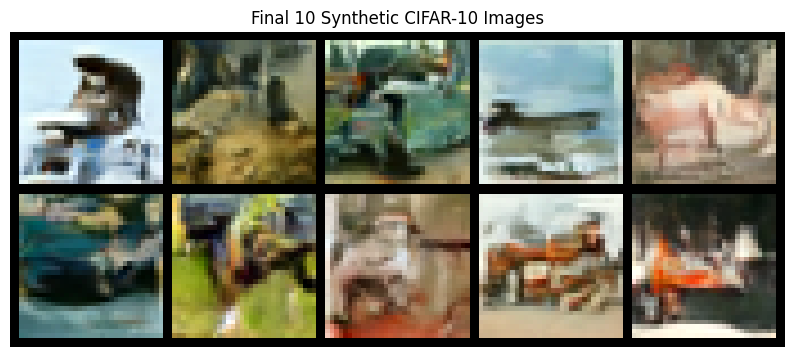

In [ ]:
# Helper to visualize training progress [cite: 92]
def visualize_progress(model, epoch):
    print(f"Sampling images for Epoch {epoch}...")
    # Generate samples [cite: 93]
    samples = sample(model, n_samples=10, steps=50)
    grid = vutils.make_grid(samples, nrow=5)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(f"Samples at Epoch {epoch}")
    plt.show()

# Run the training loop [cite: 8]
train(epochs=10)

# Final Result: Sample 10 synthetic images [cite: 93]
final_samples = sample(model, n_samples=10, steps=50)
grid = vutils.make_grid(final_samples, nrow=5)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title("Final 10 Synthetic CIFAR-10 Images")
plt.show()